In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [2]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

/home/idies/miniconda3/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [3]:
myPredictorsDf = pd.read_csv('eICUPredictorsDiag.csv')

/tmp/ipykernel_218/3248146962.py:1: DtypeWarning: Columns (14,16,41,51,63,65,66,76,80,89,99,111,113,114,124,128) have mixed types. Specify dtype option on import or set low_memory=False.
  myPredictorsDf = pd.read_csv('eICUPredictorsDiag.csv')


Index(['patientunitstayid', 'gender', 'age', 'apacheadmissiondx',
       'admissionheight', 'hospitaladmittime24', 'hospitaladmitsource',
       'admissionweight', 'PEA', 'Asystole',
       ...
       'without foley catheter', 'without gangrene',
       'without hemodynamic compromise',
       'without return to pre-existing conscious level',
       'witnessed, < 15 minutes CPR', 'witnessed, > 15 minutes CPR',
       'wound dehiscence', 'wound infection', 'wound-associated',
       'LastMGCSPositive'],
      dtype='object', length=2200)

In [4]:
# print(list(myPredictorsDf.columns))

In [5]:
# myPredictorsDf.select_dtypes(include=['object']).columns

In [6]:
# # myPredictorsDf.loc[myFilter, 'LastGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastGCS'].astype(int) > 8).astype(int
# myFilter = (myPredictorsDf['FirstGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['FirstGCS'].isna()) & (myPredictorsDf['LastGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastGCS'].isna())
# myFilter = myFilter & (myPredictorsDf['FirstMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['FirstMGCS'].isna()) & (myPredictorsDf['LastMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastMGCS'].isna())
# myFilter = myFilter & (myPredictorsDf['FirstMGCSTime'] != myPredictorsDf['LastMGCSTime']) & (myPredictorsDf['FirstGCSTime'] != myPredictorsDf['LastGCSTime'])
# myPredictorsDf.loc[myPredictorsDf['DeathAtDischarge'] == 1, 'LastMGCS'] = 1
# myPredictorsDf.gender = (myPredictorsDf.gender == 'Male').astype(int)
# myPredictorsDf.LastGCS15 = 0
# myPredictorsDf.loc[myFilter, 'LastGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastGCS'].astype(int) > 8).astype(int)
# myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastMGCS'].astype(int) == 6).astype(int)

In [4]:
# myPredictorsDf.loc[myFilter, 'LastGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastGCS'].astype(int) > 8).astype(int
# myFilter = (myPredictorsDf['LastGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastGCS'].isna())
myFilter = (myPredictorsDf['LastMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastMGCS'].isna())
myFilter = myFilter & (myPredictorsDf['FirstMGCSTime'] != myPredictorsDf['LastMGCSTime'])# & (myPredictorsDf['FirstGCSTime'] != myPredictorsDf['LastGCSTime'])
myPredictorsDf.loc[myPredictorsDf['FirstGCS'] == 'Unable to score due to medication', 'FirstGCS'] = np.nan
myPredictorsDf.loc[myPredictorsDf['FirstMGCS'] == 'Unable to score due to medication', 'FirstMGCS'] = np.nan
myPredictorsDf.loc[myPredictorsDf['LastMGCS'] == 'Unable to score due to medication', 'LastMGCS'] = np.nan
myPredictorsDf.loc[myPredictorsDf['LastGCS'] == 'Unable to score due to medication', 'LastGCS'] = np.nan
myPredictorsDf.loc[myPredictorsDf['DeathAtDischarge'] == 1, 'LastMGCS'] = 1
myPredictorsDf.gender = (myPredictorsDf.gender == 'Male').astype(int)
myPredictorsDf.LastGCS15 = 0
# myPredictorsDf.loc[myFilter, 'LastGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastGCS'].astype(float) > 8).astype(int)
myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastMGCS'].astype(float) == 6).astype(int)

In [14]:
myPredictorsDf[myFilter]

,patientunitstayid,gender,age,apacheadmissiondx,admissionheight,hospitaladmittime24,hospitaladmitsource,admissionweight,PEA,Asystole,...,without foley catheter,without gangrene,without hemodynamic compromise,without return to pre-existing conscious level,"witnessed, < 15 minutes CPR","witnessed, > 15 minutes CPR",wound dehiscence,wound infection,wound-associated,LastMGCSPositive
116,244718,0,57,Seizures (primary-no structural brain disease),154.90,02:59:00,NaN,54.70,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
117,246179,1,48,"Fracture-pathological, non-union, non-traumati...",177.80,10:32:00,Operating Room,99.00,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
119,250724,0,50,Cardiac arrest (with or without respiratory ar...,167.60,09:26:00,Emergency Department,110.20,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
120,251469,0,24,Cardiac arrest (with or without respiratory ar...,167.64,20:44:00,Direct Admit,74.69,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
121,251884,0,63,Coma/change in level of consciousness (for hep...,165.10,19:37:00,Emergency Department,92.90,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3392,3351655,1,64,Cardiac arrest (with or without respiratory ar...,160.00,00:52:00,Direct Admit,85.60,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3393,3351806,1,69,Cardiac arrest (with or without respiratory ar...,182.90,04:57:00,Emergency Department,127.80,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3395,3351912,1,42,"Hemorrhage/hematoma, intracranial",185.40,21:58:00,Emergency Department,110.90,0,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3402,3352727,0,82,"Arrest, respiratory (without cardiac arrest)",162.60,23:04:00,Direct Admit,61.40,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
myColumns = [x for x in myPredictorsDf.columns if 'emp' in x]
myXValue = myPredictorsDf.drop(columns= myColumns + [ 'LastMGCSTime', 'FirstMGCSTime', 'LastMGCSPositive', 'LastMGCS' , 'apacheadmissiondx', 'hospitaladmittime24', 'FirstGCSTime', 'LastGCSTime', 'LastGCS', 'hospitaldischargestatus', 'LastGCS15', 'hospitaladmitsource', 'DeathAtDischarge', 'patientunitstayid'])
myXValue = myXValue#[myFilter]
myXValue.FirstGCS = myXValue.FirstGCS.astype(float)
myXValue.FirstMGCS = myXValue.FirstMGCS.astype(float)
myXValue = myXValue.select_dtypes(exclude=['object'])
myYValue = myPredictorsDf['DeathAtDischarge']#[myFilter]
myYValue = myYValue.astype(int)

X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[['LastGCS15', 'Hypothermia']], test_size=0.3)

In [31]:
myGridSearchCv = gridSearchKFoldClassification(X_train=X_train, X_test = X_test, y_train = y_train, y_test=y_test, aScore='roc_auc', aGrid = DefaultGrid)
myBestModel = myGridSearchCv.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/home/idies/miniconda3/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/idies/miniconda3/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain f

[CV 5/5] END clf=XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...), clf__max_depth=5, clf__n_estimators=25;, score=0.751 total time= 1.2min
[CV 1/5] END clf=XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
        

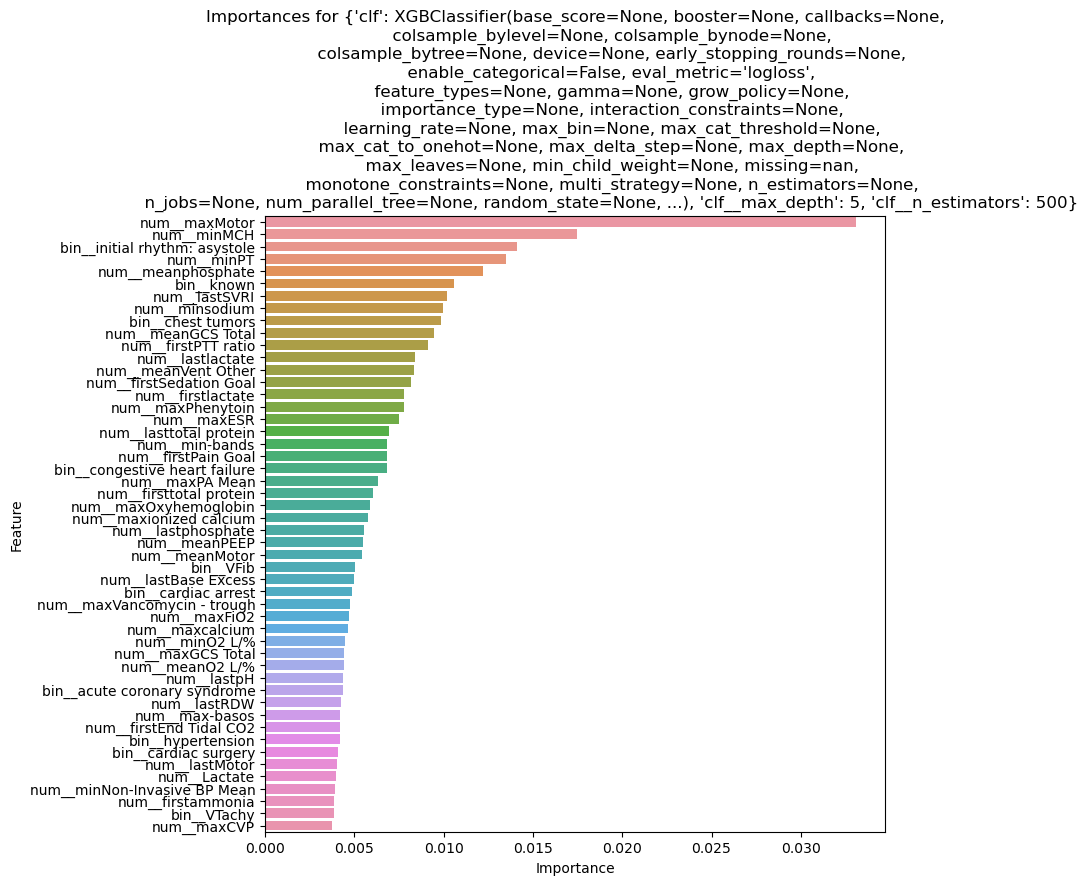

In [32]:
myFeatureImportancesDf = getTopFeatures(myGridSearchCv, list(myBestModel.named_steps.preprocessor.get_feature_names_out()), X_train, y_train)

In [34]:
myFeatureImportancesDf[myFeatureImportancesDf.Feature == 'bin__Hypothermia']

,Feature,Importance
703,bin__Hypothermia,0.000237


In [26]:
# from scikeras.wrappers import KerasClassifier
# from mlxtend.feature_selection import SequentialFeatureSelector as SFS

# # Assuming you have a function to build your Keras model
# def build_model():
#     model = keras.Sequential()
#     model.add(layers.Dense(64, activation='relu', input_shape=(X_train_transf.shape[1],)))
#     model.add(layers.Dense(32, activation='relu'))
#     model.add(layers.Dense(1, activation='sigmoid'))  # For binary classification
#     model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
#     return model

# # Wrap the model with KerasClassifier
# model_wrapper = KerasClassifier(model=build_model, epochs=10, batch_size=32, verbose=1)
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    return [('preprocessor', myPreprocessor), ('imputer', KNNImputer(n_neighbors=10))]#, ( ('sfs', SFS(LogisticRegression(), 
         #  k_features='best', 
         #  forward=True, 
         #  floating=False, 
         #  scoring='roc_auc', 
         #  cv=3,
         # verbose=1,
         # n_jobs=-1))]
def gridSearchKFoldClassification(X_train, X_test, y_train, y_test, aScore = 'roc_auc', aGrid = DefaultGrid):
    kf = StratifiedKFold(n_splits=5, shuffle=True)
    myPipelineSteps = getDefaultPipelineSteps(X_train = X_train)
    myPipelineSteps.append(('clf', XGBClassifier()))
    myPipeline = Pipeline(myPipelineSteps)
    myGridSearchCv = GridSearchCV(myPipeline, aGrid, cv=kf, scoring=aScore, n_jobs=-1, verbose=3)
    myGridSearchCv.fit(X_train, y_train)
    myBestModel = myGridSearchCv.best_estimator_
    y_pred_proba = myBestModel.predict_proba(X_test)[:, 1]
    y_pred = myBestModel.predict(X_test)
    print(f'Best parameters: {myGridSearchCv.best_params_}')
    print(f'Best cross val {aScore} score: {myGridSearchCv.best_score_:.4f}')
    print(f'Area under the receiver operating curve on test set is {roc_auc_score(y_test, y_pred_proba):.4f}')
    print(f'Accuracy score on test set is {accuracy_score(y_test, y_pred):.4f}')
    return myGridSearchCv
DefaultGrid = [
    {
        'clf': [XGBClassifier(eval_metric='logloss'), RandomForestClassifier()],
        'clf__n_estimators': [25, 50, 200, 500, 1000], 
        'clf__max_depth': [5, 10, 50, 100]
    }
    # {
    #     'clf': [DecisionTreeClassifier()],
    #     'clf__max_depth': [2, 5, 20, 50, None],
    #     'clf__class_weight': [None, 'balanced']
    # },
    # {
    #     'clf': [LogisticRegression()],
    #     'clf__C': [0.1, 1, 10]
    # }
    # {
    #     'clf': [KerasClassifier(model=build_model, epochs=30, batch_size=32, verbose=1)]
    # }
]

def getPredictedTreatmentEffectSupervisedClassif(X_train, aModel, aCategory, aGroup):
    myXValueModified1 = X_train.copy()
    myXValueModified1[aGroup] = 1.0
    myXValueModified2 = X_train.copy()
    myXValueModified2[aGroup] = 0.0
    if hasattr(aModel, 'predict_proba'):
        y_pred_proba1 = aModel.predict_proba(myXValueModified1)[:, 1]
        y_pred_proba2 = aModel.predict_proba(myXValueModified2)[:, 1]
    else:
        y_pred_proba1 = aModel.predict(myXValueModified1)
        y_pred_proba2 = aModel.predict(myXValueModified2)
    myNewDf = pd.DataFrame()
    myNewDf['predicted_effect'] = (y_pred_proba1 - y_pred_proba2)
    return plotPredictedTreatmentEffect(myNewDf=myNewDf, aCategory=aCategory)
def getTreatmentEffectDiff(X_train, y_train, aModel, aCategory = 'CPC12', aGroup = 'groupe'):
    lower_third, upper_third, myNewDf = getPredictedTreatmentEffectSupervisedClassif(X_train, aModel, aCategory, aGroup)
    print(lower_third)
    print(upper_third)
    if upper_third == lower_third:
        print(f'No effect difference')
        return 1
    myData = pd.concat([X_train[aGroup], myNewDf['predicted_effect'], y_train], axis=1)
    model1 = smf.logit(
        f'{aCategory} ~ predicted_effect + {aGroup}',
        data=myData
    ).fit()

    model2 = smf.logit(
        f'{aCategory} ~ predicted_effect * {aGroup}',
        data=myData
    ).fit()

    llr = -2*(model1.llf - model2.llf)
    df_diff = model2.df_model - model1.df_model
    p_value = chi2.sf(llr, df_diff)

    print(f'Likelihood ratio of test results:')
    print(f'Chi square statistic: {llr}')
    print(f'p-value: {p_value}')
    print(f'Degress of freedom: {df_diff}')
    print(f'NonInteraction p-value: {model1.summary()}')
    print(f'Interaction p-value: {model2.summary()}')
    return p_value

-3.063678741455084e-05
0.00023072957992553692
Optimization terminated successfully.
         Current function value: 0.689515
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.689376
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 0.4628193965158971
p-value: 0.49630926391855146
Degress of freedom: 1.0
NonInteraction p-value:                            Logit Regression Results                           
Dep. Variable:       DeathAtDischarge   No. Observations:                 1659
Model:                          Logit   Df Residuals:                     1656
Method:                           MLE   Df Model:                            2
Date:                Mon, 17 Feb 2025   Pseudo R-squ.:                0.002880
Time:                        16:37:49   Log-Likelihood:                -1143.9
converged:                       True   LL-Null:                       -1147.2
Covariance Type:            nonrobust   LLR p

0.49630926391855146

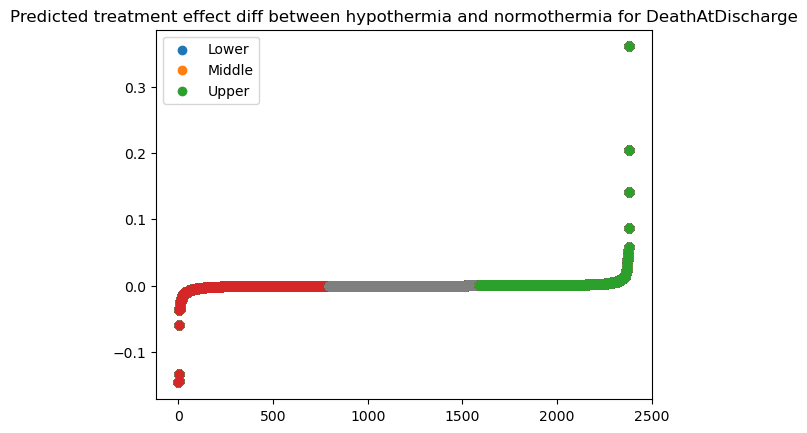

In [33]:
# getTreatmentEffectDiff(myXValue, myYValue, myBestModel, 'LastGCS15', 'Hypothermia')
# myNewDf = pd.DataFrame()
# myNewDf['predicted_effect_group'] = myBestModel.predic D Dt(X_test)
getTreatmentEffectDiff(X_train, y_train, myBestModel, 'DeathAtDischarge', 'Hypothermia')

-0.006000000000000005
0.001999999999999974
Optimization terminated successfully.
         Current function value: 0.654791
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.654027
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 1.0572722026490737
p-value: 0.589408314933102
Degress of freedom: 2.0
NonInteraction p-value:                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                  692
Model:                          Logit   Df Residuals:                      688
Method:                           MLE   Df Model:                            3
Date:                Sun, 02 Feb 2025   Pseudo R-squ.:                 0.01808
Time:                        19:09:05   Log-Likelihood:                -453.12
converged:                       True   LL-Null:                       -461.46
Covariance Type:            nonrobust   LLR p-valu

0.589408314933102

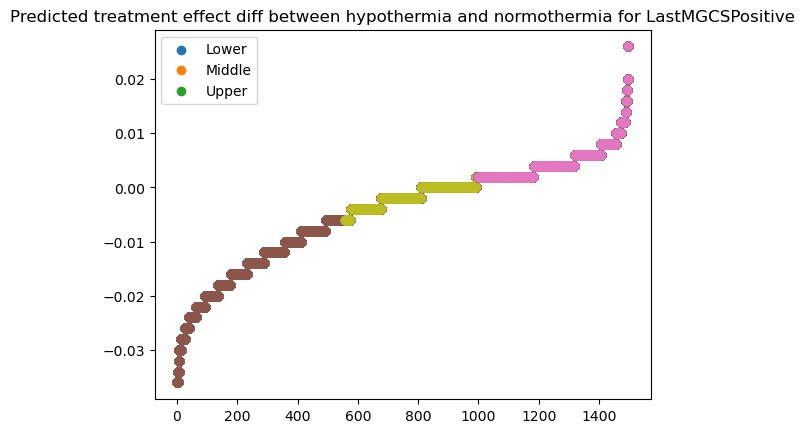

In [29]:
getTreatmentEffectDiff(X_train, y_train, myBestModel, 'LastMGCSPositive', 'Hypothermia')